# Object Size vs Difficulty Score Analysis

This notebook checks whether smaller objects tend to have higher difficulty scores.

It will:
- Load object-level scores from one score_results.json file
- Compute object size (pixel area when image size is available)
- Compute Pearson and Spearman correlations between size and score
- Visualize score trends by size

In [3]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

try:
    import pandas as pd
except Exception:
    pd = None

try:
    from PIL import Image
except Exception:
    Image = None

# Choose one score file to analyze
# SCORE_PATH = Path("/home/khanh/Projects/DifficultyAgri/.cache_result/no_trad_aug/gwhd/scoring/seed_123/score_results.json")

# Other useful options:
# SCORE_PATH = Path("/home/khanh/Projects/DifficultyAgri/.cache_result/with_trad_aug/gwhd/scoring/seed_123/score_results.json")
# SCORE_PATH = Path("/home/khanh/Projects/DifficultyAgri/.cache_result/no_trad_aug/minneapple/scoring/seed_123/score_results.json")
SCORE_PATH = Path("/home/khanh/Projects/DifficultyAgri/.cache_result/with_trad_aug/minneapple/scoring/seed_123/score_results.json")

if not SCORE_PATH.exists():
    raise FileNotFoundError(f"Score file not found: {SCORE_PATH}")

with open(SCORE_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

image_difficulties = data.get("image_difficulties", [])
if not isinstance(image_difficulties, list) or len(image_difficulties) == 0:
    raise ValueError("No image_difficulties found in score file")

# Cache image width/height when available
image_size_cache = {}


def get_image_size(image_path: str):
    p = Path(image_path)
    if p in image_size_cache:
        return image_size_cache[p]
    if Image is None or (not p.exists()):
        image_size_cache[p] = None
        return None
    try:
        with Image.open(p) as im:
            wh = (int(im.width), int(im.height))
            image_size_cache[p] = wh
            return wh
    except Exception:
        image_size_cache[p] = None
        return None


rows = []
for img in image_difficulties:
    image_path = img.get("image_path", "")
    objects = img.get("objects_score", [])
    if not isinstance(objects, list):
        continue

    wh = get_image_size(image_path)
    for obj in objects:
        score = obj.get("difficulty_score", None)
        bbox = obj.get("bounding_box", {})
        w = bbox.get("width", None)
        h = bbox.get("height", None)

        if score is None or w is None or h is None:
            continue

        w = float(w)
        h = float(h)
        area_norm = max(0.0, w) * max(0.0, h)

        if wh is not None:
            img_w, img_h = wh
            area_px = area_norm * img_w * img_h
        else:
            area_px = np.nan

        rows.append(
            {
                "image_path": image_path,
                "difficulty_score": float(score),
                "width_norm": w,
                "height_norm": h,
                "area_norm": area_norm,
                "area_px": float(area_px) if not np.isnan(area_px) else np.nan,
            }
        )

if len(rows) == 0:
    raise ValueError("No valid object rows extracted from score file")

if pd is not None:
    df = pd.DataFrame(rows)
else:
    # Minimal fallback structure
    df = rows

print(f"Loaded objects: {len(rows)}")
print(f"Images in file: {len(image_difficulties)}")

Loaded objects: 22815
Images in file: 536


Using pixel area for correlation
N objects used: 22815

Correlation between size and score:
Pearson(log10(area), score):   -0.618827
Spearman(log10(area), score):  -0.679701

Correlation between smaller-size indicator and score:
Pearson(1/area, score):        0.186580
Spearman(1/area, score):       0.679702

Interpretation: smaller objects tend to have higher difficulty scores.


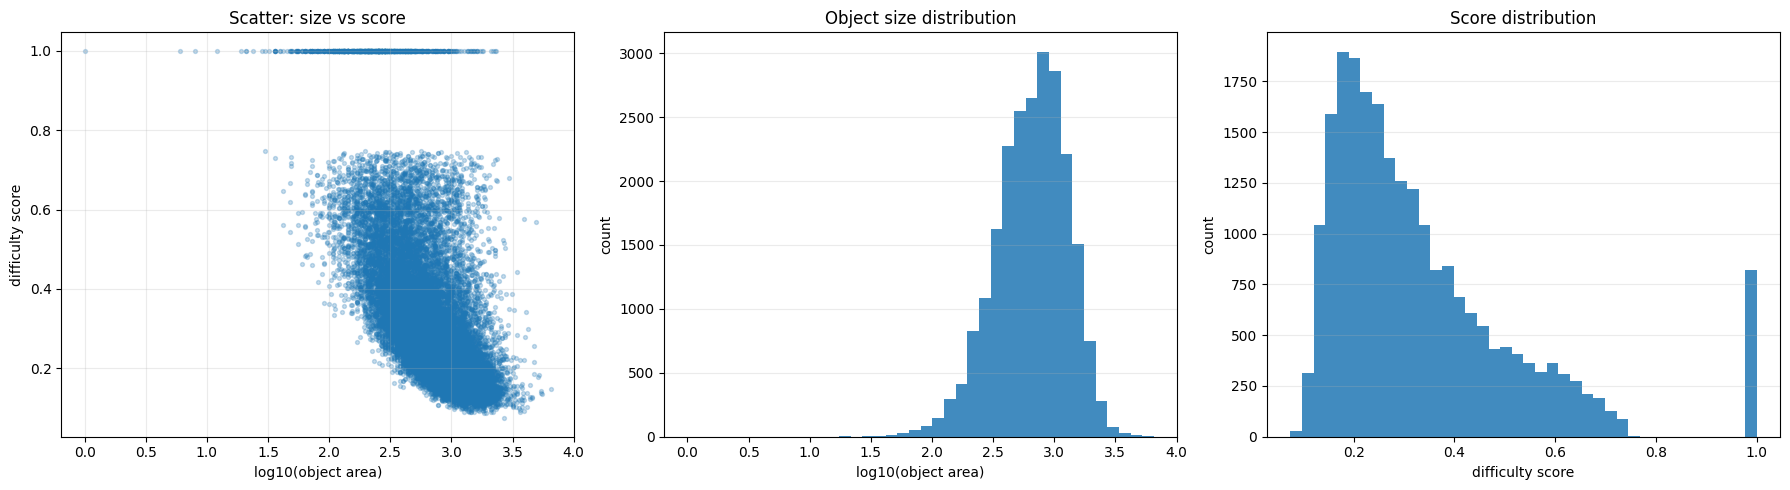

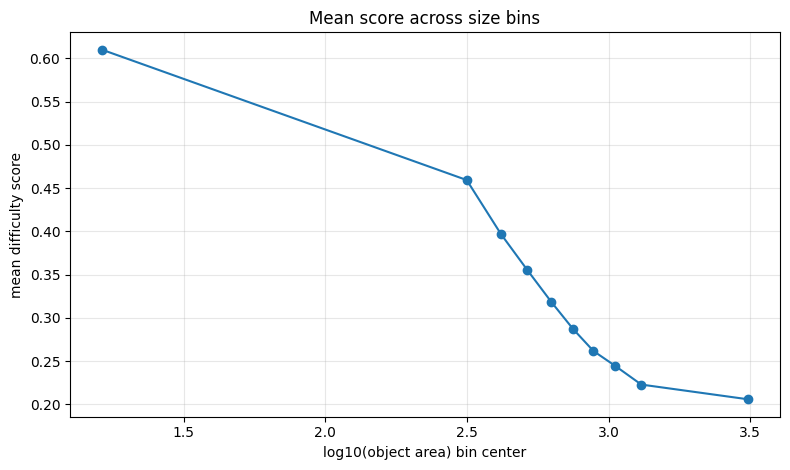

,bin_center_log10_area,n_objects,mean_score
0,1.212387,2301,0.609776
1,2.498881,2286,0.459232
2,2.619696,2272,0.396828
3,2.711961,2308,0.355619
4,2.798133,2262,0.318102
5,2.874205,2273,0.287129
6,2.946373,2278,0.261598
7,3.023067,2312,0.244442
8,3.115133,2246,0.222839
9,3.490951,2277,0.205860


In [4]:
def rankdata(arr: np.ndarray) -> np.ndarray:
    order = np.argsort(arr)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(len(arr), dtype=float)
    _, inv, counts = np.unique(arr, return_inverse=True, return_counts=True)
    for i, c in enumerate(counts):
        if c > 1:
            idx = np.where(inv == i)[0]
            ranks[idx] = ranks[idx].mean()
    return ranks + 1.0


def safe_pearson(x: np.ndarray, y: np.ndarray) -> float:
    if len(x) < 2:
        return float("nan")
    if np.allclose(x, x[0]) or np.allclose(y, y[0]):
        return float("nan")
    return float(np.corrcoef(x, y)[0, 1])


def safe_spearman(x: np.ndarray, y: np.ndarray) -> float:
    if len(x) < 2:
        return float("nan")
    return safe_pearson(rankdata(x), rankdata(y))


if pd is not None:
    work = df.copy()
else:
    # Convert fallback list to arrays
    area_norm = np.array([r["area_norm"] for r in df], dtype=float)
    score = np.array([r["difficulty_score"] for r in df], dtype=float)
    area_px = np.array([r["area_px"] for r in df], dtype=float)
    work = None

if work is not None:
    # Use pixel area when available; otherwise fallback to normalized area
    use_px = (~work["area_px"].isna()).sum() > 0
    work["area_used"] = work["area_px"] if use_px else work["area_norm"]
    work = work[np.isfinite(work["area_used"]) & np.isfinite(work["difficulty_score"])].copy()
    work = work[work["area_used"] > 0].copy()

    x_area = work["area_used"].to_numpy(dtype=float)
    y_score = work["difficulty_score"].to_numpy(dtype=float)
else:
    use_px = np.isfinite(area_px).sum() > 0
    x_area = area_px if use_px else area_norm
    keep = np.isfinite(x_area) & np.isfinite(score) & (x_area > 0)
    x_area = x_area[keep]
    y_score = score[keep]

x_log_area = np.log10(x_area)
x_inv_area = 1.0 / x_area

pearson_log = safe_pearson(x_log_area, y_score)
spearman_log = safe_spearman(x_log_area, y_score)
pearson_inv = safe_pearson(x_inv_area, y_score)
spearman_inv = safe_spearman(x_inv_area, y_score)

unit = "pixel area" if use_px else "normalized area"
print(f"Using {unit} for correlation")
print(f"N objects used: {len(y_score)}")
print()
print("Correlation between size and score:")
print(f"Pearson(log10(area), score):   {pearson_log:.6f}")
print(f"Spearman(log10(area), score):  {spearman_log:.6f}")
print()
print("Correlation between smaller-size indicator and score:")
print(f"Pearson(1/area, score):        {pearson_inv:.6f}")
print(f"Spearman(1/area, score):       {spearman_inv:.6f}")

if spearman_log < 0:
    print("\nInterpretation: smaller objects tend to have higher difficulty scores.")
elif spearman_log > 0:
    print("\nInterpretation: larger objects tend to have higher difficulty scores.")
else:
    print("\nInterpretation: no monotonic relationship detected.")

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(x_log_area, y_score, s=8, alpha=0.25)
axes[0].set_xlabel("log10(object area)")
axes[0].set_ylabel("difficulty score")
axes[0].set_title("Scatter: size vs score")
axes[0].grid(alpha=0.25)

axes[1].hist(x_log_area, bins=40, alpha=0.85)
axes[1].set_xlabel("log10(object area)")
axes[1].set_ylabel("count")
axes[1].set_title("Object size distribution")
axes[1].grid(axis="y", alpha=0.25)

axes[2].hist(y_score, bins=40, alpha=0.85)
axes[2].set_xlabel("difficulty score")
axes[2].set_ylabel("count")
axes[2].set_title("Score distribution")
axes[2].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

# Score-by-size bins
n_bins = 10
quantile_edges = np.quantile(x_log_area, np.linspace(0, 1, n_bins + 1))
quantile_edges = np.unique(quantile_edges)
if len(quantile_edges) >= 3:
    bin_ids = np.digitize(x_log_area, quantile_edges[1:-1], right=True)
    mean_score_per_bin = []
    center_per_bin = []
    count_per_bin = []
    for b in range(len(quantile_edges) - 1):
        m = bin_ids == b
        if np.any(m):
            mean_score_per_bin.append(float(np.mean(y_score[m])))
            center_per_bin.append(float(0.5 * (quantile_edges[b] + quantile_edges[b + 1])))
            count_per_bin.append(int(np.sum(m)))

    plt.figure(figsize=(8, 4.8))
    plt.plot(center_per_bin, mean_score_per_bin, marker="o")
    plt.xlabel("log10(object area) bin center")
    plt.ylabel("mean difficulty score")
    plt.title("Mean score across size bins")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    if pd is not None:
        summary = pd.DataFrame(
            {
                "bin_center_log10_area": center_per_bin,
                "n_objects": count_per_bin,
                "mean_score": mean_score_per_bin,
            }
        )
        display(summary)
